earthkit-data cache: trying to free 4.6 GiB
earthkit-data cache: could not free 4.6 GiB
earthkit-data cache: trying to free 4.6 GiB                                                                                                                                                                                 
Deleting entry {
    "path": "/var/folders/vt/7j2c2tmx4m14gn_sg3zpf5l00000gn/T/earthkit-data-mavj/url-f7b4664508556f0f4bde38de60c7e523b3b0361b3710911ef11c8e5fba7e520a.nc",
    "owner": "url",
    "args": {
        "url": [
            "https://sites.ecmwf.int/repository/earthkit/samples/era5-monthly-mean-2t-199312.nc"
        ],
        "parts": [
            null
        ]
    },
    "creation_date": "2026-03-13 09:24:01.310254",
    "flags": 0,
    "owner_data": {
        "server": "nginx",
        "date": "Fri, 13 Mar 2026 09:24:01 GMT",
        "content-type": "application/octet-stream; charset=utf-8",
        "content-length": "2086196",
        "connection": "keep-alive",
    

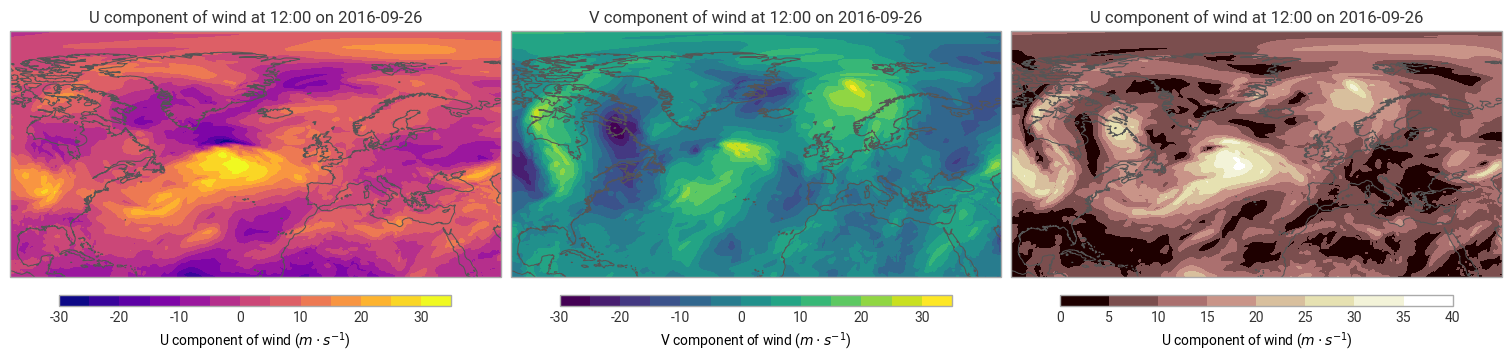

In [1]:
import earthkit.data as ekd
from earthkit.meteo import wind
import earthkit.plots as ekp

ds = ekd.from_source("sample", "era5_tquv_pl_subarea.nc").to_xarray()
sp = wind.speed(ds.u,ds.v)
sp.attrs["standard_name"] = "wind_speed"
sp = sp.rename("ws")

u = ds.u.sel(pressure_level=700, valid_time="2016-09-26T12")
v = ds.v.sel(pressure_level=700, valid_time="2016-09-26T12")
sp1 = sp.sel(pressure_level=700, valid_time="2016-09-26T12")
ekp.geo.plot(u, v, sp1)
 

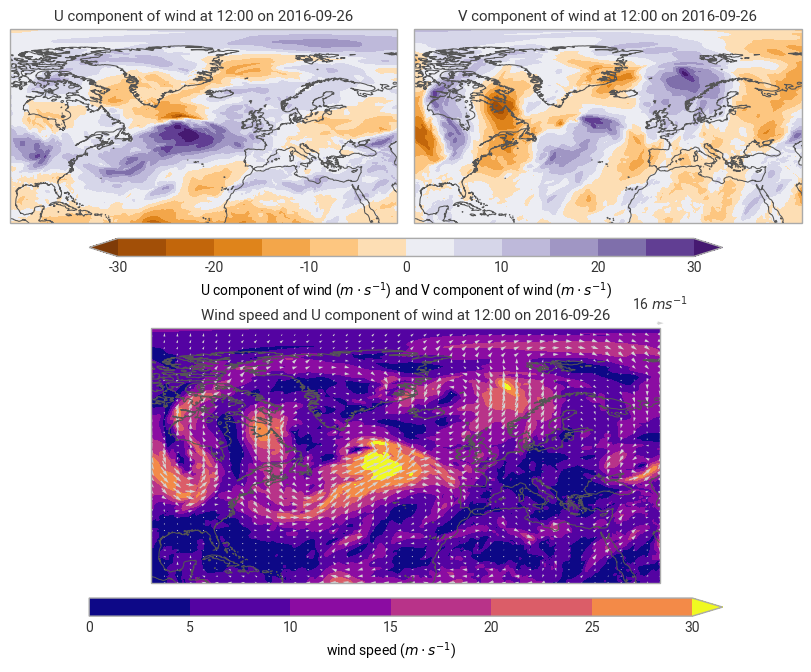

In [2]:
import earthkit.data as ekd
from earthkit.meteo import wind
import earthkit.plots as ekp

ds = ekd.from_source("sample", "era5_tquv_pl_subarea.nc").to_xarray()
sp = wind.speed(ds.u,ds.v)
sp.attrs["standard_name"] = "wind_speed"
sp = sp.rename("ws")

u = ds.u.sel(pressure_level=700, valid_time="2016-09-26T12")
v = ds.v.sel(pressure_level=700, valid_time="2016-09-26T12")
sp1 = sp.sel(pressure_level=700, valid_time="2016-09-26T12")
sp1.attrs["long_name"] = "wind speed"

uv_style = ekp.styles.Style(colors="PuOr", levels=range(-30, 31, 5), extend="both")
ws_style = ekp.styles.Style(colors="plasma", levels=range(0, 31, 5), extend="max")

fig = ekp.Figure(rows=2, columns=2)

fig.add_map().plot(u, style=uv_style)
fig.add_map().plot(v, style=uv_style)

ws_plot = fig.add_map(row=1, column=slice(0, 2))
ws_plot.plot(sp1, style=ws_style)
ws_plot.quiver(u, v, color="lightgrey")

fig.coastlines()

fig.subplot_titles()

fig.legend()

fig.show()

In [3]:
sp1

<xarray.DataArray 'ws' (latitude: 301, longitude: 601)> Size: 1MB
dask.array<getitem, shape=(301, 601), dtype=float64, chunksize=(301, 601), chunktype=numpy.ndarray>
Coordinates:
  * latitude        (latitude) float64 2kB 90.0 89.75 89.5 ... 15.5 15.25 15.0
  * longitude       (longitude) float64 5kB -100.0 -99.75 -99.5 ... 49.75 50.0
    number          int64 8B 0
    valid_time      datetime64[ns] 8B 2016-09-26T12:00:00
    pressure_level  float64 8B 700.0
    expver          <U4 16B dask.array<chunksize=(), meta=np.ndarray>
Attributes: (12/31)
    GRIB_paramId:                             131
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      180901
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           u
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                wind speed
    units:                                    m s**-1
    standard_name:                            wind_speed